In [52]:
import numpy as np
import pandas as pd
import joblib
from app.features.tabular import engineer_tab_features

import sys
sys.path.append("..")  # para importar app/ do diretório pai

def predict_df(df: pd.DataFrame, *, artifacts=None, model_path: str|None=None) -> pd.DataFrame:
    """
    Adiciona colunas proba_H (float) e pred (0/1) ao df, usando o mesmo pré-processamento do treino.
    Passe artifacts (dict carregado em memória) OU model_path (joblib).
    """
    if artifacts is None:
        if not model_path:
            raise ValueError("Forneça artifacts ou model_path.")
        artifacts = joblib.load(model_path)

    emb_pipe = artifacts["embedding_pipeline"]
    tab_pipe = artifacts["tabular_pipeline"]
    model = artifacts["model"]
    best_thr = artifacts.get("best_threshold", 0.5)
    tab_cfg = artifacts.get("tabular_config", {})
    tab_mode = tab_cfg.get("tab_mode", "latlon_time")

    # Embeddings -> matriz 2D
    embedding_matrix = np.vstack(df["embedding"].values)
    emb_cols = [f"emb_{i}" for i in range(embedding_matrix.shape[1])]
    df_embs = pd.DataFrame(embedding_matrix, columns=emb_cols, index=df.index)

    # Features tabulares (usa a mesma config salva no treino, incl. IBGE)
    df_tab, _ = engineer_tab_features(
        df,
        mode=tab_mode,
        urban_areas_path="../" + tab_cfg.get("urban_areas_path"),
        urban_layer=tab_cfg.get("urban_layer"),
        urban_radius_km=tab_cfg.get("urban_radius_km", 5.0),
    )

    # Transformar e prever
    X_emb = emb_pipe.transform(df_embs)
    X_tab = tab_pipe.transform(df_tab)
    X = np.hstack([X_emb, X_tab])
    proba = model.predict_proba(X)[:, 1]
    pred = (proba >= best_thr).astype(int)

    out = df.copy()
    out["proba_H"] = proba
    out["pred"] = pred
    return out

# Exemplo de uso (se você quiser evitar carregar arquivos, passe artifacts já em memória)
# artifacts = joblib.load("outputs/final_model_pca/final_model.joblib")  # ou já fornecido
# df_preds = predict_df(df, artifacts=artifacts)

In [53]:
artifacts = joblib.load("../outputs/tests/urban_geopy/final_model.joblib")

In [54]:
paths = ['../data/aurita_location_fixed.csv', '../data/jacchus_location_fixed.csv', '../data/penicillata_location_fixed.csv']
df = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)

In [55]:
embeddings_path = "../outputs/embeddings/embeddings_yolo_processed.parquet"
embeddings = pd.read_parquet(embeddings_path).set_index("Index")
embeddings

,observed_on,latitude,longitude,place_county_name,place_state_name,url,image_url,tipo,processed_image_path,yolo_meta,embedding
Index,,,,,,,,,,,
0,10/04/2005,-22.415519,-43.398463,Petrópolis,Rio de Janeiro,https://www.inaturalist.org/observations/18312...,https://static.inaturalist.org/photos/31942517...,N-H,data/processed_dataset_yolo/images/9a455def42b...,"{""bbox_xyxy"": [92, 25, 438, 275], ""bbox_raw_xy...","[0.9194355, 1.1006176, 0.23752856, -0.35192624..."
1,01/05/2006,-21.925034,-42.871454,Além Paraíba,Minas Gerais,https://www.inaturalist.org/observations/12180677,https://inaturalist-open-data.s3.amazonaws.com...,N-H,data/processed_dataset_yolo/images/d0852c410df...,"{""fallback"": ""center_crop_no_detection""}","[0.32927716, 0.60870576, 0.8404001, 1.0598605,..."
2,23/10/2009,-22.273861,-47.564140,Rio Claro,São Paulo,https://www.inaturalist.org/observations/37692783,https://inaturalist-open-data.s3.amazonaws.com...,N-H,data/processed_dataset_yolo/images/e14bf2435d9...,"{""fallback"": ""center_crop_no_detection""}","[-0.03932529, -0.022186235, 0.20645249, 0.2408..."
3,21/05/2011,-21.868276,-42.896158,Além Paraíba,Minas Gerais,https://www.inaturalist.org/observations/26091...,https://inaturalist-open-data.s3.amazonaws.com...,N-H,data/processed_dataset_yolo/images/ae64ef325ec...,"{""bbox_xyxy"": [110, 44, 250, 425], ""bbox_raw_x...","[0.10454179, 0.41960177, -0.11107793, -0.61085..."
4,01/07/2011,-23.159688,-44.820074,Cunha,São Paulo,https://www.inaturalist.org/observations/11533...,https://static.inaturalist.org/photos/19468824...,N-H,data/processed_dataset_yolo/images/891bae78000...,"{""bbox_xyxy"": [168, 30, 285, 204], ""bbox_raw_x...","[-0.66835773, 0.73358655, -0.62481254, -0.1697..."
...,...,...,...,...,...,...,...,...,...,...,...
2628,23/05/2025,-23.812307,-46.727787,São Paulo,São Paulo,https://www.inaturalist.org/observations/27495...,https://inaturalist-open-data.s3.amazonaws.com...,N-H,data/processed_dataset_yolo/images/ee6c544cbe7...,"{""fallback"": ""center_crop_no_detection""}","[0.3195901, 0.74755263, 0.51778424, -0.5003581..."
2629,24/05/2025,-19.856460,-43.996424,Belo Horizonte,Minas Gerais,https://www.inaturalist.org/observations/27509...,https://inaturalist-open-data.s3.amazonaws.com...,N-H,data/processed_dataset_yolo/images/adc14ddd5fb...,"{""bbox_xyxy"": [335, 124, 414, 256], ""bbox_raw_...","[0.49633884, 1.5899174, 0.766993, -1.0990577, ..."
2630,25/05/2025,-23.812307,-46.727787,São Paulo,São Paulo,https://www.inaturalist.org/observations/27528...,https://inaturalist-open-data.s3.amazonaws.com...,N-H,data/processed_dataset_yolo/images/8748ab897dd...,"{""fallback"": ""center_crop_no_detection""}","[-0.21770304, 1.6578704, 0.53227204, -1.408821..."


In [56]:
df = pd.merge(df, embeddings[["image_url", "embedding"]], on="image_url", how="inner")

In [57]:
df['embedding_size'] = df['embedding'].apply(lambda x: x.shape[0] if isinstance(x, np.ndarray) else None)
df['embedding_size'].isna().sum()

np.int64(0)

In [58]:
df_preds = predict_df(df, artifacts=artifacts)
df_preds

/Users/costaleirbag/Library/Caches/pypoetry/virtualenvs/saguis-dinov3-Xs5mxBYf-py3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,observed_on,latitude,longitude,place_county_name,place_state_name,url,image_url,tipo,embedding,embedding_size,proba_H,pred
0,10/04/2005,-22.415519,-43.398463,Petrópolis,Rio de Janeiro,https://www.inaturalist.org/observations/18312...,https://static.inaturalist.org/photos/31942517...,N-H,"[0.9194355, 1.1006176, 0.23752856, -0.35192624...",768,0.197130,0
1,01/05/2006,-21.925034,-42.871454,Além Paraíba,Minas Gerais,https://www.inaturalist.org/observations/12180677,https://inaturalist-open-data.s3.amazonaws.com...,N-H,"[0.32927716, 0.60870576, 0.8404001, 1.0598605,...",768,0.275308,0
2,23/10/2009,-22.273861,-47.564140,Rio Claro,São Paulo,https://www.inaturalist.org/observations/37692783,https://inaturalist-open-data.s3.amazonaws.com...,N-H,"[-0.03932529, -0.022186235, 0.20645249, 0.2408...",768,0.261285,0
3,21/05/2011,-21.868276,-42.896158,Além Paraíba,Minas Gerais,https://www.inaturalist.org/observations/26091...,https://inaturalist-open-data.s3.amazonaws.com...,N-H,"[0.10454179, 0.41960177, -0.11107793, -0.61085...",768,0.227283,0
4,01/07/2011,-23.159688,-44.820074,Cunha,São Paulo,https://www.inaturalist.org/observations/11533...,https://static.inaturalist.org/photos/19468824...,N-H,"[-0.66835773, 0.73358655, -0.62481254, -0.1697...",768,0.298034,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2549,23/05/2025,-23.812307,-46.727787,São Paulo,São Paulo,https://www.inaturalist.org/observations/27495...,https://inaturalist-open-data.s3.amazonaws.com...,N-H,"[0.3195901, 0.74755263, 0.51778424, -0.5003581...",768,0.300222,0
2550,24/05/2025,-19.856460,-43.996424,Belo Horizonte,Minas Gerais,https://www.inaturalist.org/observations/27509...,https://inaturalist-open-data.s3.amazonaws.com...,N-H,"[0.49633884, 1.5899174, 0.766993, -1.0990577, ...",768,0.205411,0
2551,25/05/2025,-23.812307,-46.727787,São Paulo,São Paulo,https://www.inaturalist.org/observations/27528...,https://inaturalist-open-data.s3.amazonaws.com...,N-H,"[-0.21770304, 1.6578704, 0.53227204, -1.408821...",768,0.341154,0
2552,25/05/2025,-23.599366,-46.934498,Cotia,São Paulo,https://www.inaturalist.org/observations/27591...,https://inaturalist-open-data.s3.amazonaws.com...,N-H,"[0.057686195, 1.6722122, 0.20997113, -1.223401...",768,0.350633,0


In [80]:
positive_df = df_preds[df_preds['tipo'] == 'H'][['observed_on', 'latitude', 'longitude', 'image_url', 'proba_H']]
positive_df

,observed_on,latitude,longitude,image_url,proba_H
11,09/10/2013,-23.460988,-45.166608,https://static.inaturalist.org/photos/34290317...,0.498459
12,09/10/2013,-23.551854,-45.148283,https://static.inaturalist.org/photos/34290319...,0.341757
17,17/01/2015,-20.977236,-42.085014,https://inaturalist-open-data.s3.amazonaws.com...,0.510576
21,27/01/2016,-23.406851,-46.752262,https://inaturalist-open-data.s3.amazonaws.com...,0.511217
26,26/05/2016,-23.423778,-46.793164,https://inaturalist-open-data.s3.amazonaws.com...,0.610342
...,...,...,...,...,...
2463,27/02/2025,-22.970142,-46.434500,https://static.inaturalist.org/photos/46042718...,0.556994
2470,08/03/2025,-23.727336,-46.583550,https://static.inaturalist.org/photos/46317466...,0.421064
2487,24/03/2025,-23.457783,-47.210929,https://inaturalist-open-data.s3.amazonaws.com...,0.549733
2525,28/04/2025,-20.579597,-47.870931,https://inaturalist-open-data.s3.amazonaws.com...,0.491869


In [81]:
for _, row in positive_df.sample(5).iterrows():
    print(row["observed_on"])
    print(f"{row['latitude']}, {row['longitude']}")
    print(f"{row['image_url']}")
    print(row['proba_H'])
    print("\n")

14/06/2022
-23.5438686236, -46.760838914
https://inaturalist-open-data.s3.amazonaws.com/photos/199431875/medium.jpeg
0.4909019278661497


03/03/2024
-23.3385243121, -45.8019630966
https://inaturalist-open-data.s3.amazonaws.com/photos/355437444/medium.jpg
0.4712957707741657


27/03/2023
-18.8660224366, -41.9326615169
https://inaturalist-open-data.s3.amazonaws.com/photos/351666620/medium.jpeg
0.21702521809325767


01/02/2021
-23.1410111, -46.9317805
https://static.inaturalist.org/photos/107723114/medium.jpg
0.3428440663035435


19/09/2020
-22.9673873143, -43.2229435113
https://static.inaturalist.org/photos/83813847/medium.jpeg
0.6518508798688055




TypeError: tuple indices must be integers or slices, not str

Recall H: 0.85
Precision H: 0.80
Accuracy: 0.89
AUC: 0.95


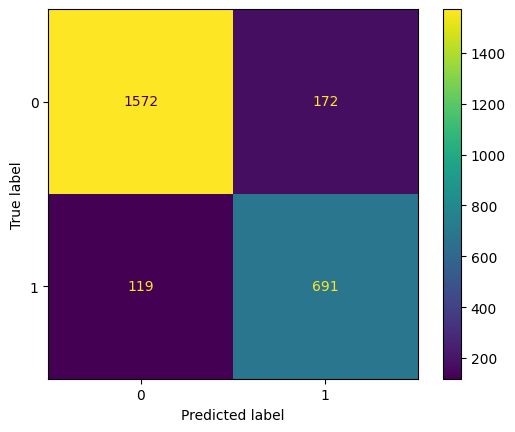

In [72]:
# Compare df_preds['pred'] with df_preds['tipo'].replace({'H': 1, 'N-H': 0}); confusion matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score

cm = confusion_matrix(df_preds['tipo'].map({'H': 1, 'N-H': 0}), df_preds['pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
print(f"Recall H: {cm[1,1] / (cm[1,0] + cm[1,1]):.2f}")
print(f"Precision H: {cm[1,1] / (cm[0,1] + cm[1,1]):.2f}")
print(f"Accuracy: {(cm[0,0] + cm[1,1]) / cm.sum():.2f}")
print(f"AUC: {roc_auc_score(df_preds['tipo'].map({'H': 1, 'N-H': 0}), df_preds['proba_H']):.2f}")
disp.plot();